# Valorant Win Predictor — Model Training
**Model A** → Pre-round win probability (economy + ults + score)  
**Model B** → Live win probability (updates on every kill)

Sections:
1. Setup & Load
2. Train Model A (pre-round)
3. Train Model B (live)
4. Evaluate both models
5. Feature importance
6. Save models


In [6]:
!pip install xgboost


## 1. Setup & Load

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (accuracy_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "font.size"        : 11,
})
BLUE = "#2a78d6"; ORANGE = "#eb6834"; GREEN = "#1baf7a"; RED = "#e34948"


In [8]:
# ── Load data ────────────────────────────────────────────────────────────
pre_train  = pd.read_csv("processed/pre_round_train.csv")
pre_test   = pd.read_csv("processed/pre_round_test.csv")
live_train = pd.read_csv("processed/live_round_train.csv")
live_test  = pd.read_csv("processed/live_round_test.csv")

# ── Feature definitions ───────────────────────────────────────────────────
A_FEATURES = [
    "att_money", "def_money", "economy_diff",
    "att_full_buy", "def_full_buy", "att_eco", "def_eco",
    "att_ults_ready", "def_ults_ready", "ult_adv",
    "score_won", "score_lost", "score_diff",
    "round_number", "local_team_side", "map"
]

B_FEATURES = [
    "att_money", "def_money", "economy_diff",
    "att_full_buy", "def_full_buy", "att_eco", "def_eco",
    "att_ults_ready", "def_ults_ready", "ult_adv",
    "score_won", "score_lost", "score_diff",
    "att_alive", "def_alive", "alive_diff", "alive_ratio",
    "att_kills", "def_kills", "kill_diff",
    "att_wiping", "def_wiping",
    "spike_planted", "kill_index", "kill_progress",
    "round_number", "local_team_side", "map"
]

TARGET = "winner"

# ── Split X / y ───────────────────────────────────────────────────────────
X_train_a = pre_train[A_FEATURES]
y_train_a = pre_train[TARGET]
X_test_a  = pre_test[A_FEATURES]
y_test_a  = pre_test[TARGET]

X_train_b = live_train[B_FEATURES]
y_train_b = live_train[TARGET]
X_test_b  = live_test[B_FEATURES]
y_test_b  = live_test[TARGET]

print(f"Model A — train: {X_train_a.shape}  test: {X_test_a.shape}")
print(f"Model B — train: {X_train_b.shape}  test: {X_test_b.shape}")
print(f"Class balance A train: {y_train_a.value_counts().to_dict()}")
print(f"Class balance B train: {y_train_b.value_counts().to_dict()}")


Model A — train: (1170, 16)  test: (287, 16)
Model B — train: (8123, 28)  test: (1980, 28)
Class balance A train: {1: 609, 0: 561}
Class balance B train: {1: 4247, 0: 3876}


## 2. Train Model A — Pre-round predictor

In [9]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# XGBoost — tree-based, handles raw features perfectly, no scaling needed
MODEL_A_PARAMS = dict(
    n_estimators      = 300,
    max_depth         = 4,        # shallow — pre-round is a simpler problem
    learning_rate     = 0.05,
    subsample         = 0.8,      # row sampling — reduces overfitting
    colsample_bytree  = 0.8,      # feature sampling per tree
    min_child_weight  = 5,        # minimum samples per leaf
    gamma             = 0.1,      # minimum loss reduction to split
    eval_metric       = "logloss",
    random_state      = 42,
    verbosity         = 0,
)

model_a = XGBClassifier(**MODEL_A_PARAMS)


In [10]:
# ── Cross-validation (5-fold) ─────────────────────────────────────────────
# Using StratifiedKFold to maintain class balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc  = cross_val_score(model_a, X_train_a, y_train_a, cv=cv, scoring="accuracy")
cv_auc  = cross_val_score(model_a, X_train_a, y_train_a, cv=cv, scoring="roc_auc")

print("Model A — 5-fold CV results:")
print(f"  Accuracy : {cv_acc.mean():.3f} ± {cv_acc.std():.3f}  per fold: {cv_acc.round(3).tolist()}")
print(f"  ROC-AUC  : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}  per fold: {cv_auc.round(3).tolist()}")


Model A — 5-fold CV results:
  Accuracy : 0.703 ± 0.024  per fold: [0.705, 0.679, 0.697, 0.748, 0.684]
  ROC-AUC  : 0.780 ± 0.022  per fold: [0.777, 0.766, 0.753, 0.817, 0.786]


In [12]:
# ── Train on full training set ────────────────────────────────────────────
model_a.fit(
    X_train_a, y_train_a,
    eval_set=[(X_test_a, y_test_a)],
    verbose=False
)

# ── Test set evaluation ───────────────────────────────────────────────────
y_pred_a  = model_a.predict(X_test_a)
y_prob_a  = model_a.predict_proba(X_test_a)[:, 1]

acc_a = accuracy_score(y_test_a, y_pred_a)
auc_a = roc_auc_score(y_test_a, y_prob_a)

print(f"Model A — Test set results:")
print(f"  Accuracy : {acc_a:.3f}  ({acc_a*100:.1f}%)")
print(f"  ROC-AUC  : {auc_a:.3f}")
print()
print("Classification report:")
print(classification_report(y_test_a, y_pred_a, target_names=["enemies win","allies win"]))


Model A — Test set results:
  Accuracy : 0.739  (73.9%)
  ROC-AUC  : 0.809

Classification report:
              precision    recall  f1-score   support

 enemies win       0.70      0.82      0.76       142
  allies win       0.79      0.66      0.72       145

    accuracy                           0.74       287
   macro avg       0.74      0.74      0.74       287
weighted avg       0.75      0.74      0.74       287



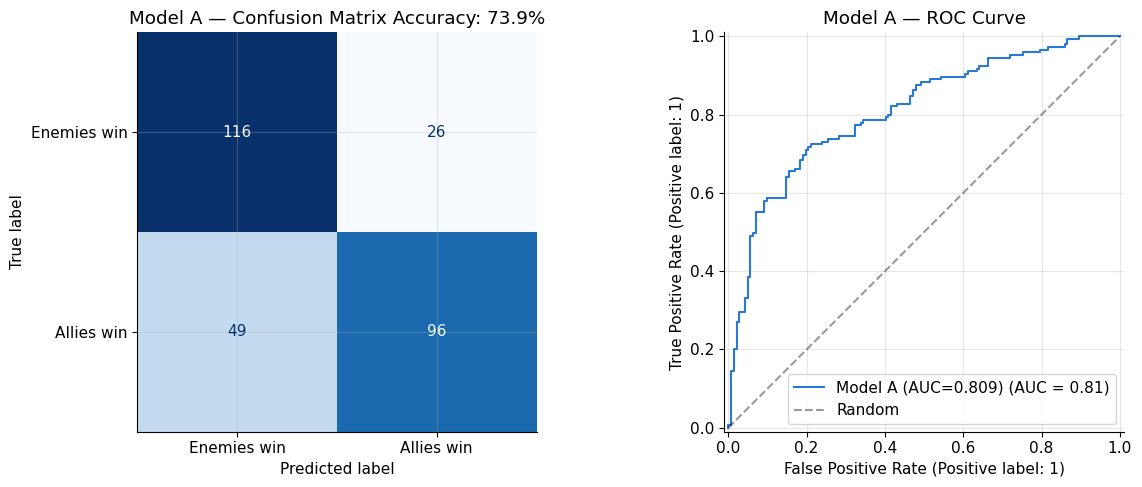

In [15]:
# ── Confusion matrix + ROC curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test_a, y_pred_a)
disp = ConfusionMatrixDisplay(cm, display_labels=["Enemies win","Allies win"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Model A — Confusion Matrix Accuracy: {acc_a*100:.1f}%")

# ROC Curve
RocCurveDisplay.from_predictions(y_test_a, y_prob_a, ax=axes[1],
                                  name=f"Model A (AUC={auc_a:.3f})",
                                  color=BLUE)
axes[1].plot([0,1],[0,1], "k--", alpha=0.4, label="Random")
axes[1].set_title("Model A — ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Train Model B — Live predictor

In [16]:
MODEL_B_PARAMS = dict(
    n_estimators      = 400,
    max_depth         = 5,        # slightly deeper — more complex live state
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 10,       # higher — live data has many rows, avoid overfitting
    gamma             = 0.1,
    eval_metric       = "logloss",
    random_state      = 42,
    verbosity         = 0,
)

model_b = XGBClassifier(**MODEL_B_PARAMS)


In [17]:
# ── Cross-validation ─────────────────────────────────────────────────────
cv_acc_b = cross_val_score(model_b, X_train_b, y_train_b, cv=cv, scoring="accuracy")
cv_auc_b = cross_val_score(model_b, X_train_b, y_train_b, cv=cv, scoring="roc_auc")

print("Model B — 5-fold CV results:")
print(f"  Accuracy : {cv_acc_b.mean():.3f} ± {cv_acc_b.std():.3f}  per fold: {cv_acc_b.round(3).tolist()}")
print(f"  ROC-AUC  : {cv_auc_b.mean():.3f} ± {cv_auc_b.std():.3f}  per fold: {cv_auc_b.round(3).tolist()}")


Model B — 5-fold CV results:
  Accuracy : 0.953 ± 0.002  per fold: [0.952, 0.95, 0.956, 0.953, 0.953]
  ROC-AUC  : 0.991 ± 0.001  per fold: [0.992, 0.989, 0.991, 0.99, 0.992]


In [18]:
# ── Train on full training set ────────────────────────────────────────────
model_b.fit(
    X_train_b, y_train_b,
    eval_set=[(X_test_b, y_test_b)],
    verbose=False
)

# ── Test set evaluation ───────────────────────────────────────────────────
y_pred_b = model_b.predict(X_test_b)
y_prob_b = model_b.predict_proba(X_test_b)[:, 1]

acc_b = accuracy_score(y_test_b, y_pred_b)
auc_b = roc_auc_score(y_test_b, y_prob_b)

print(f"Model B — Test set results:")
print(f"  Accuracy : {acc_b:.3f}  ({acc_b*100:.1f}%)")
print(f"  ROC-AUC  : {auc_b:.3f}")
print()
print("Classification report:")
print(classification_report(y_test_b, y_pred_b, target_names=["enemies win","allies win"]))


Model B — Test set results:
  Accuracy : 0.728  (72.8%)
  ROC-AUC  : 0.803

Classification report:
              precision    recall  f1-score   support

 enemies win       0.71      0.77      0.74       990
  allies win       0.75      0.68      0.72       990

    accuracy                           0.73      1980
   macro avg       0.73      0.73      0.73      1980
weighted avg       0.73      0.73      0.73      1980



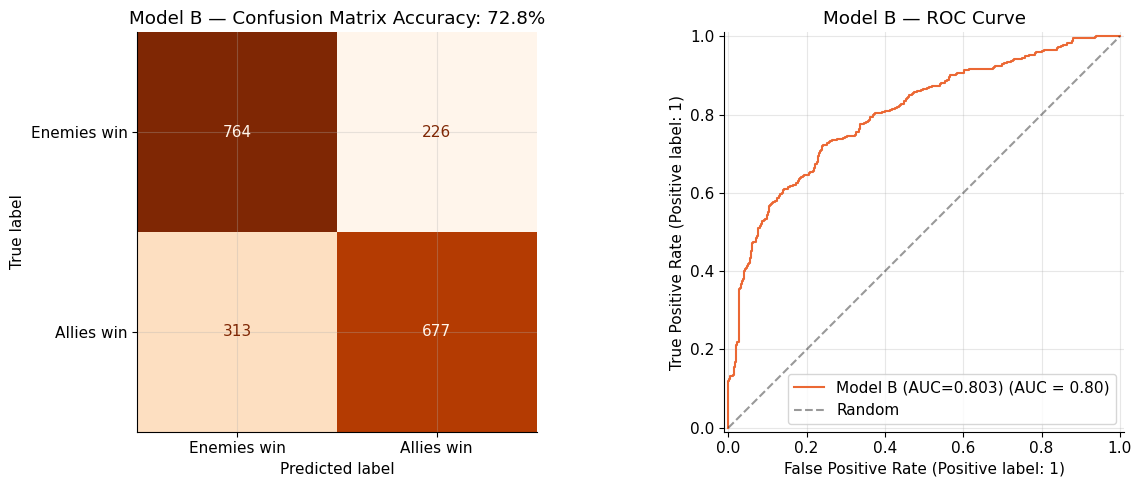

In [20]:
# ── Confusion matrix + ROC curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_b = confusion_matrix(y_test_b, y_pred_b)
ConfusionMatrixDisplay(cm_b, display_labels=["Enemies win","Allies win"]).plot(
    ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title(f"Model B — Confusion Matrix Accuracy: {acc_b*100:.1f}%")

RocCurveDisplay.from_predictions(y_test_b, y_prob_b, ax=axes[1],
                                  name=f"Model B (AUC={auc_b:.3f})",
                                  color=ORANGE)
axes[1].plot([0,1],[0,1], "k--", alpha=0.4, label="Random")
axes[1].set_title("Model B — ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Model Comparison

In [21]:
# ── Side-by-side summary ─────────────────────────────────────────────────
print("="*45)
print(f"{'':20} {'Model A':>10} {'Model B':>10}")
print("-"*45)
print(f"{'CV Accuracy':20} {cv_acc.mean():>10.3f} {cv_acc_b.mean():>10.3f}")
print(f"{'CV AUC':20} {cv_auc.mean():>10.3f} {cv_auc_b.mean():>10.3f}")
print(f"{'Test Accuracy':20} {acc_a:>10.3f} {acc_b:>10.3f}")
print(f"{'Test AUC':20} {auc_a:>10.3f} {auc_b:>10.3f}")
print(f"{'Train rows':20} {len(X_train_a):>10,} {len(X_train_b):>10,}")
print(f"{'Features':20} {len(A_FEATURES):>10} {len(B_FEATURES):>10}")
print("="*45)


                        Model A    Model B
---------------------------------------------
CV Accuracy               0.703      0.953
CV AUC                    0.780      0.991
Test Accuracy             0.739      0.728
Test AUC                  0.809      0.803
Train rows                1,170      8,123
Features                     16         28


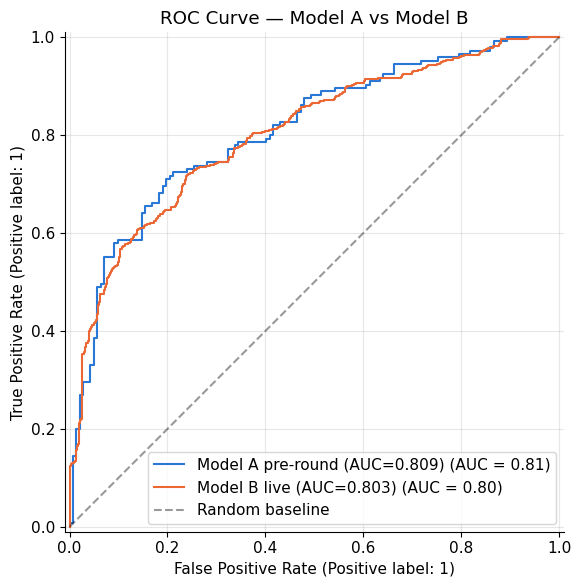

In [22]:
# ── ROC curves together ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test_a, y_prob_a, ax=ax,
                                  name=f"Model A pre-round (AUC={auc_a:.3f})",
                                  color=BLUE)
RocCurveDisplay.from_predictions(y_test_b, y_prob_b, ax=ax,
                                  name=f"Model B live (AUC={auc_b:.3f})",
                                  color=ORANGE)
ax.plot([0,1],[0,1], "k--", alpha=0.4, label="Random baseline")
ax.set_title("ROC Curve — Model A vs Model B")
ax.legend()
plt.tight_layout()
plt.show()


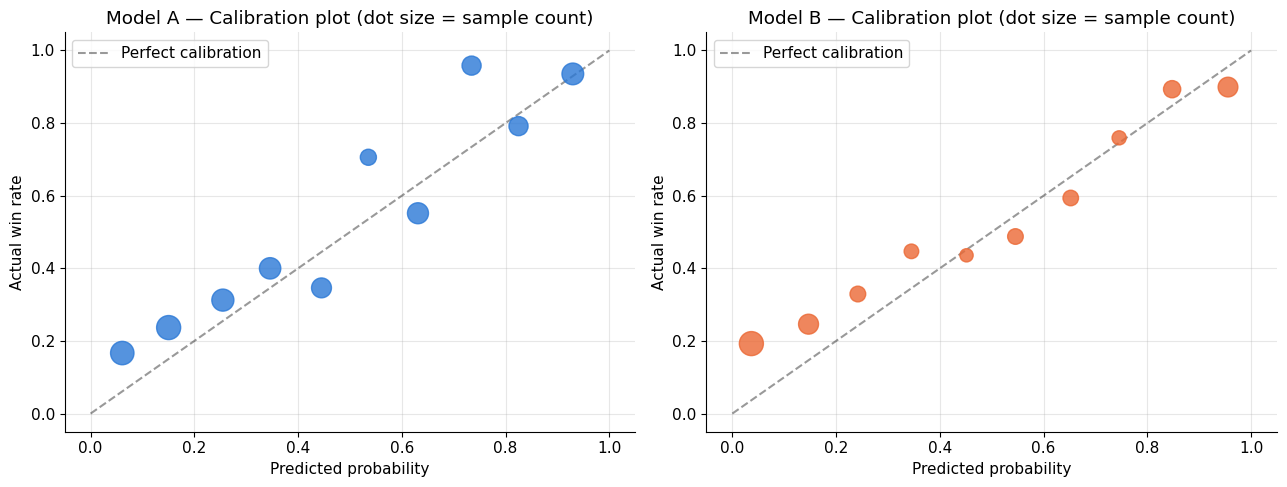

Points close to the diagonal = well calibrated probabilities


In [25]:
# ── Probability calibration check ────────────────────────────────────────
# Are the probabilities well-calibrated? (does 70% predicted = 70% actual?)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_prob, label, color in [
    (axes[0], y_test_a, y_prob_a, "Model A", BLUE),
    (axes[1], y_test_b, y_prob_b, "Model B", ORANGE),
]:
    df_cal = pd.DataFrame({"prob": y_prob, "actual": y_true})
    df_cal["bucket"] = pd.cut(df_cal["prob"], bins=10)
    cal = df_cal.groupby("bucket", observed=True).agg(
        mean_pred=("prob", "mean"),
        mean_actual=("actual", "mean"),
        count=("actual", "count")
    ).dropna()

    ax.scatter(cal["mean_pred"], cal["mean_actual"],s=cal["count"]/cal["count"].max()*300,color=color, alpha=0.8, zorder=3)
    ax.plot([0,1],[0,1], "k--", alpha=0.4, label="Perfect calibration")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Actual win rate")
    ax.set_title(f"{label} — Calibration plot (dot size = sample count)")
    ax.legend()

plt.tight_layout()
plt.show()
print("Points close to the diagonal = well calibrated probabilities")


## 5. Feature Importance

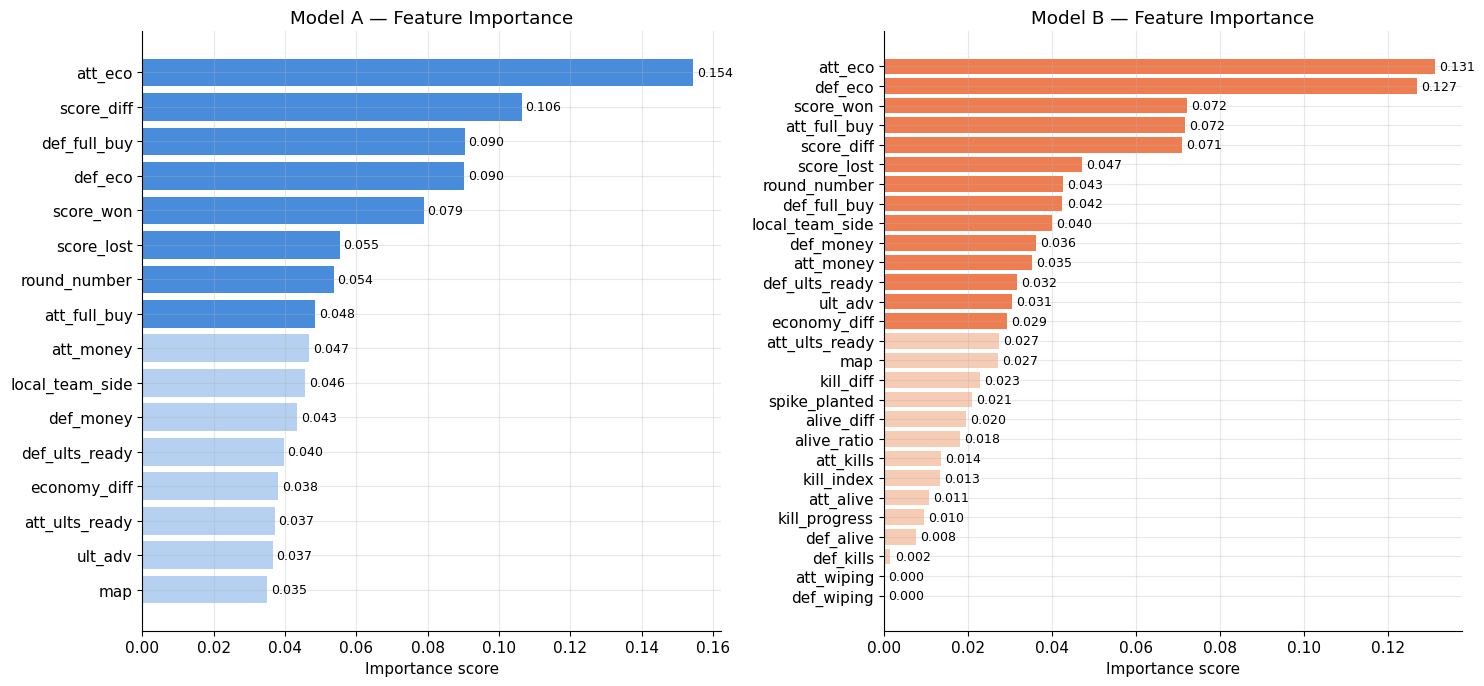

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Model A
fi_a = pd.Series(model_a.feature_importances_, index=A_FEATURES).sort_values()
colors_a = [BLUE if v > fi_a.median() else "#aac8ef" for v in fi_a.values]
axes[0].barh(fi_a.index, fi_a.values, color=colors_a, alpha=0.85)
axes[0].set_title("Model A — Feature Importance")
axes[0].set_xlabel("Importance score")
for i, v in enumerate(fi_a.values):
    axes[0].text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)

# Model B
fi_b = pd.Series(model_b.feature_importances_, index=B_FEATURES).sort_values()
colors_b = [ORANGE if v > fi_b.median() else "#f5c4a8" for v in fi_b.values]
axes[1].barh(fi_b.index, fi_b.values, color=colors_b, alpha=0.85)
axes[1].set_title("Model B — Feature Importance")
axes[1].set_xlabel("Importance score")
for i, v in enumerate(fi_b.values):
    axes[1].text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


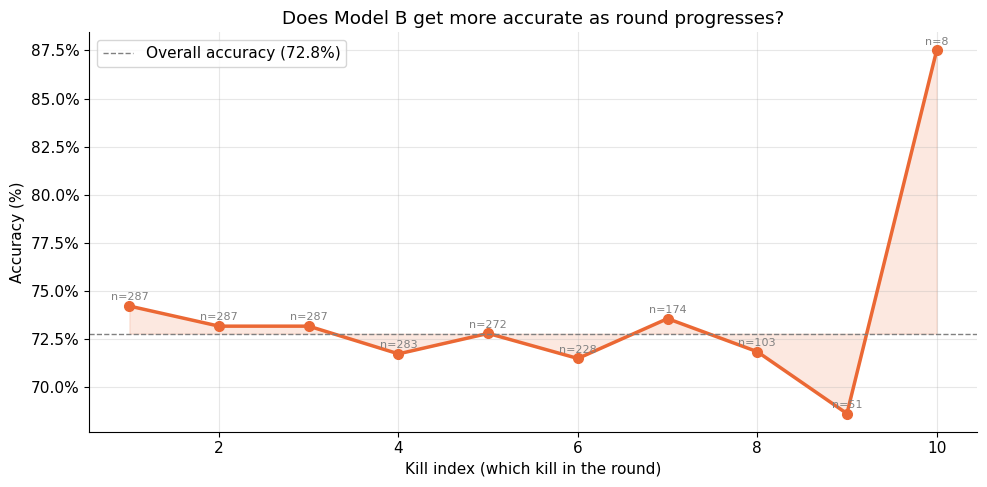

In [27]:
# ── Win probability by kill index (does Model B get better as round goes on?)
fig, ax = plt.subplots(figsize=(10, 5))

live_test_copy = live_test.copy()
live_test_copy["pred_prob"] = y_prob_b
live_test_copy["correct"]   = (y_pred_b == y_test_b).astype(int)

acc_by_kill = live_test_copy.groupby("kill_index")["correct"].mean()
n_by_kill   = live_test_copy.groupby("kill_index").size()

ax.plot(acc_by_kill.index, acc_by_kill.values * 100,
        color=ORANGE, linewidth=2.5, marker="o", markersize=7)
ax.axhline(acc_b * 100, color="gray", linewidth=1, linestyle="--",
           label=f"Overall accuracy ({acc_b*100:.1f}%)")
ax.fill_between(acc_by_kill.index, acc_b * 100, acc_by_kill.values * 100,
                alpha=0.15, color=ORANGE)
ax.set_xlabel("Kill index (which kill in the round)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Does Model B get more accurate as round progresses?")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

# Add sample count labels
for ki, n in n_by_kill.items():
    ax.text(ki, acc_by_kill[ki]*100 + 0.3, f"n={n}", ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()


## 6. Sanity Checks — Do predictions make sense?

In [28]:
# Test with hand-crafted scenarios — does the model output sensible probabilities?
scenarios = [
    {"name": "ATT full buy (22k) vs DEF eco (3k), leading 8-4",
     "pre": dict(att_money=22000, def_money=3000, economy_diff=19000,
                  att_full_buy=1, def_full_buy=0, att_eco=0, def_eco=1,
                  att_ults_ready=2, def_ults_ready=0, ult_adv=2,
                  score_won=8, score_lost=4, score_diff=4,
                  round_number=13, local_team_side=1, map=2),
     "live": dict(att_alive=5, def_alive=2, alive_diff=3, alive_ratio=0.71,
                   att_kills=3, def_kills=0, kill_diff=3,
                   att_wiping=1, def_wiping=0, spike_planted=1,
                   kill_index=3, kill_progress=0.33)},

    {"name": "Both eco (4k vs 4k), score tied 6-6",
     "pre": dict(att_money=4000, def_money=4000, economy_diff=0,
                  att_full_buy=0, def_full_buy=0, att_eco=1, def_eco=1,
                  att_ults_ready=0, def_ults_ready=0, ult_adv=0,
                  score_won=6, score_lost=6, score_diff=0,
                  round_number=13, local_team_side=0, map=3),
     "live": dict(att_alive=3, def_alive=3, alive_diff=0, alive_ratio=0.5,
                   att_kills=2, def_kills=2, kill_diff=0,
                   att_wiping=0, def_wiping=0, spike_planted=0,
                   kill_index=4, kill_progress=0.44)},

    {"name": "DEF full buy (25k) vs ATT eco (2k), DEF leading 10-3",
     "pre": dict(att_money=2000, def_money=25000, economy_diff=-23000,
                  att_full_buy=0, def_full_buy=1, att_eco=1, def_eco=0,
                  att_ults_ready=0, def_ults_ready=3, ult_adv=-3,
                  score_won=3, score_lost=10, score_diff=-7,
                  round_number=14, local_team_side=1, map=1),
     "live": dict(att_alive=1, def_alive=5, alive_diff=-4, alive_ratio=0.17,
                   att_kills=0, def_kills=4, kill_diff=-4,
                   att_wiping=0, def_wiping=1, spike_planted=0,
                   kill_index=4, kill_progress=0.44)},
]

print(f"{'Scenario':<50} {'Model A':>10} {'Model B':>10}")
print("-" * 72)
for sc in scenarios:
    pre_row  = pd.DataFrame([sc["pre"]])[A_FEATURES]
    live_row = pd.DataFrame([{**sc["pre"], **sc["live"]}])[B_FEATURES]
    pa = model_a.predict_proba(pre_row)[0][1] * 100
    pb = model_b.predict_proba(live_row)[0][1] * 100
    print(f"{sc['name']:<50} {pa:>9.1f}% {pb:>9.1f}%")

print()
print("Expected: Scenario 1 → high allies, Scenario 2 → ~50%, Scenario 3 → low allies")


Scenario                                              Model A    Model B
------------------------------------------------------------------------
ATT full buy (22k) vs DEF eco (3k), leading 8-4         54.1%      30.2%
Both eco (4k vs 4k), score tied 6-6                     35.9%      26.0%
DEF full buy (25k) vs ATT eco (2k), DEF leading 10-3       8.5%       1.6%

Expected: Scenario 1 → high allies, Scenario 2 → ~50%, Scenario 3 → low allies


## 7. Save Models

In [ ]:
os.makedirs("models", exist_ok=True)

# Save models
with open("models/model_a.pkl", "wb") as f: pickle.dump(model_a, f)
with open("models/model_b.pkl", "wb") as f: pickle.dump(model_b, f)

# Save metadata — needed by the backend to reconstruct inputs
metadata = {
    "a_features"  : A_FEATURES,
    "b_features"  : B_FEATURES,
    "target"      : TARGET,
    "model_a_acc" : round(acc_a, 4),
    "model_a_auc" : round(auc_a, 4),
    "model_b_acc" : round(acc_b, 4),
    "model_b_auc" : round(auc_b, 4),
    "map_values"  : sorted(pre_train["map"].unique().tolist()),
    "side_values" : sorted(pre_train["local_team_side"].unique().tolist()),
}
with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(f"  models/model_a.pkl   ({os.path.getsize('models/model_a.pkl')//1024} KB)")
print(f"  models/model_b.pkl   ({os.path.getsize('models/model_b.pkl')//1024} KB)")
print(f"  models/metadata.json")
print()
print(f"Final results:")
print(f"  Model A → Accuracy: {acc_a*100:.1f}%  AUC: {auc_a:.3f}")
print(f"  Model B → Accuracy: {acc_b*100:.1f}%  AUC: {auc_b:.3f}")
print()
print("Next step: Phase 3 — Python WebSocket backend")
